### 0. Importing modules and data

In [38]:
import pandas as pd
from edastatmil_milser import edas_tatmil as EDA
import os

In [39]:

raw_df = pd.read_csv('../data/raw/Diabetes.csv')
raw_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 1. Objective

The goal is to predict based on diagnostic measures whether a patient has diabetes or not. Therefore, the target variable will be 'Outcome', where 0 indicates negative for diabetes and 1 indicates positive.

### 2.Exploration and superficial cleaning

In [40]:
categorical, numerical = EDA.explore(raw_df)

Rows: 768
Columns: 9
+--------------------------+----------------+------------+-----------+---------------+
|                          | Non-Null Count | Null Count | Data Type | Data Category |
+--------------------------+----------------+------------+-----------+---------------+
|       Pregnancies        |      768       |     0      |   int64   |   Numerical   |
|         Glucose          |      768       |     0      |   int64   |   Numerical   |
|      BloodPressure       |      768       |     0      |   int64   |   Numerical   |
|      SkinThickness       |      768       |     0      |   int64   |   Numerical   |
|         Insulin          |      768       |     0      |   int64   |   Numerical   |
|           BMI            |      768       |     0      |  float64  |   Numerical   |
| DiabetesPedigreeFunction |      768       |     0      |  float64  |   Numerical   |
|           Age            |      768       |     0      |   int64   |   Numerical   |
|         Outcome     

It's a small dataset with no null values and all numeric columns, although our target variable is actually categorical and already factorized. All the information is relevant, so we don't eliminate any features a priori.

### 3. Univarite analysis

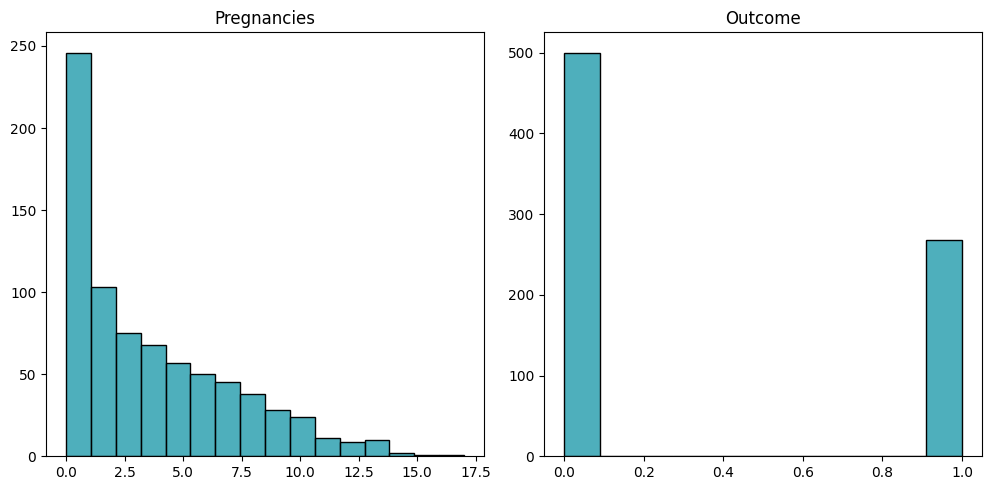

In [41]:
EDA.univariate_hist(['Pregnancies','Outcome'], raw_df)

In [42]:
aprox_H = (raw_df['Pregnancies'] != 0).sum()
aprox_V = (raw_df['Pregnancies'] == 0).sum()

print('N woman aprox:', aprox_H)
print('N men aprox:', aprox_V)

N woman aprox: 657
N men aprox: 111


Given that we don't have the sex of the individual, adding the number of individuals who have had at least one pregnancy and those who have not had any can give us a rough idea of the number of men and women in the dataset. In this case, although there may be many women who have not had children, the difference is wide enough to make us wonder if training the model with this data could induce a bias that makes better predictions for women than for men..

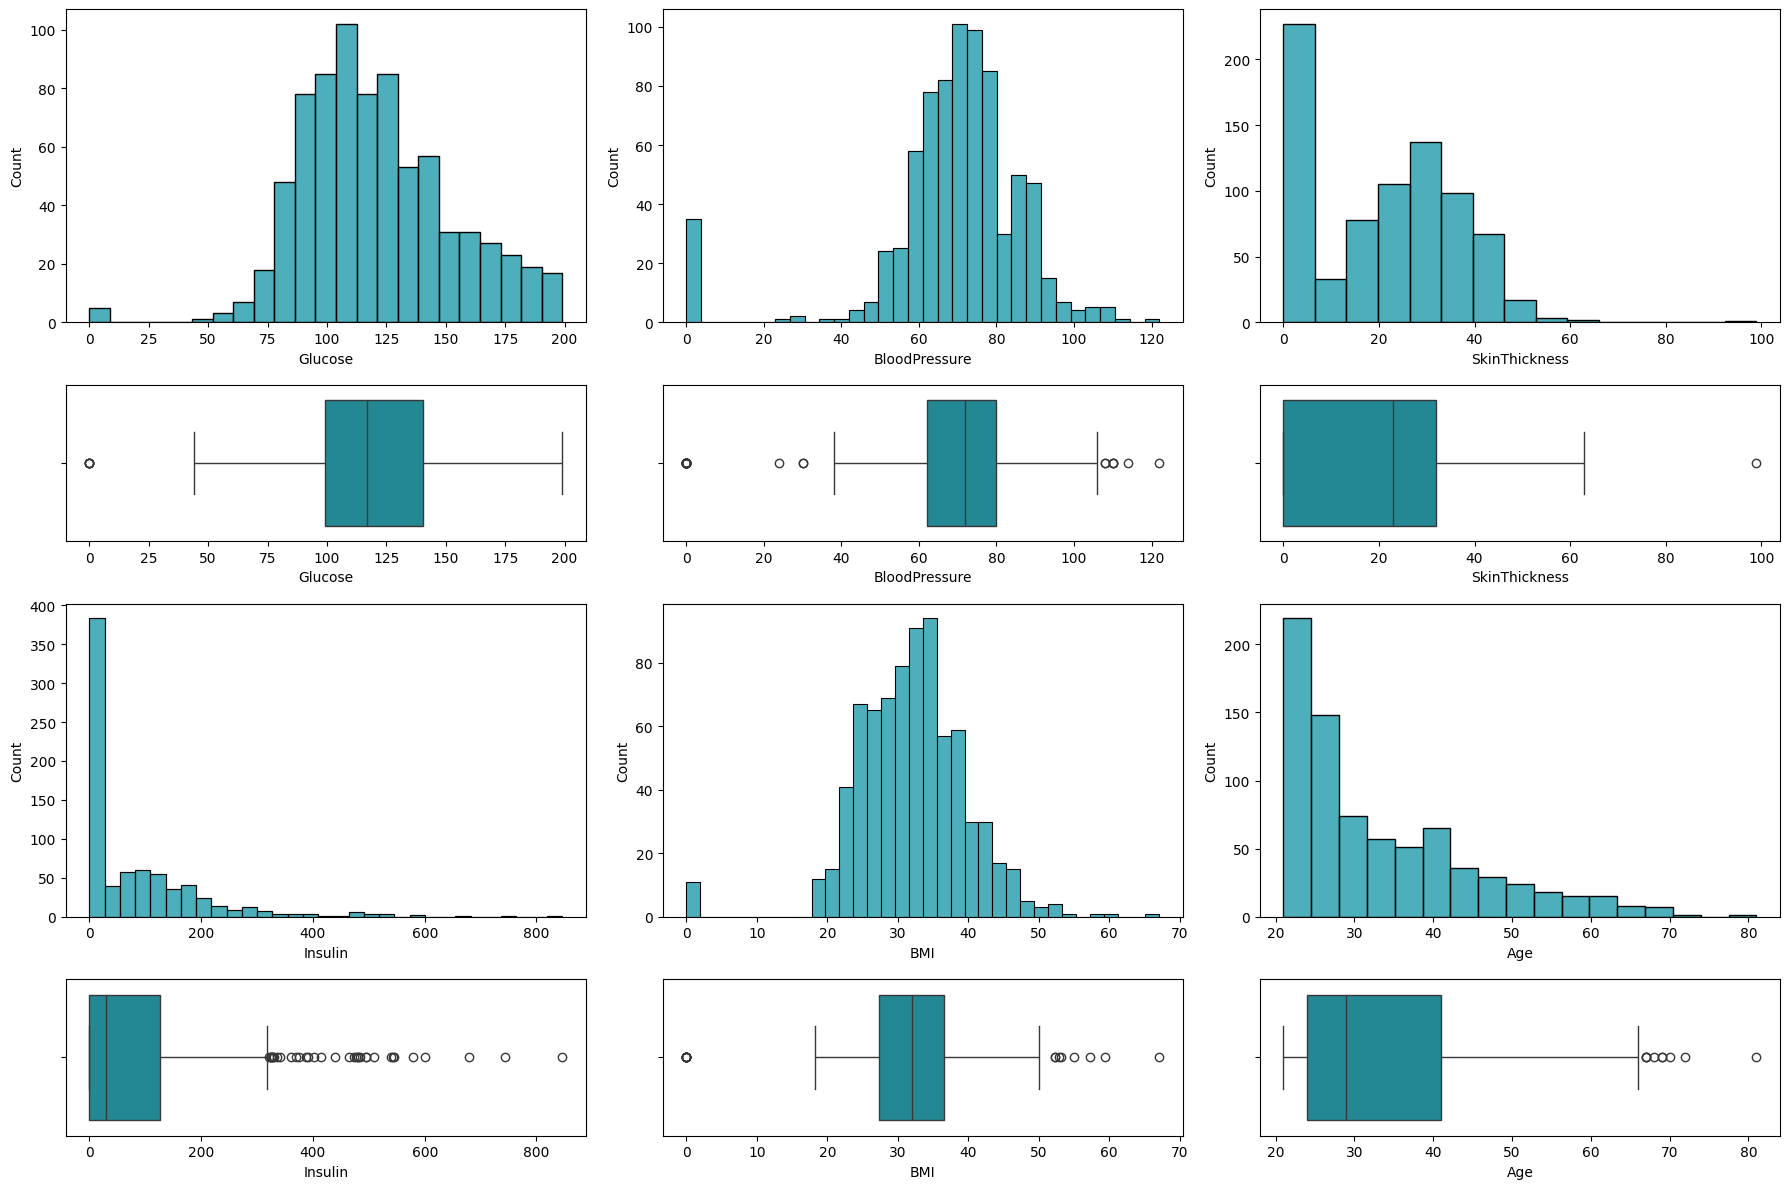

In [43]:
EDA.univariate_histbox(['Glucose','BloodPressure','SkinThickness','Insulin','BMI','Age'], raw_df)

In general, the data seems fairly well grouped, although some outliers are observed that will need to be treated later.

### 4. Multivariate analysis

In [44]:
raw_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

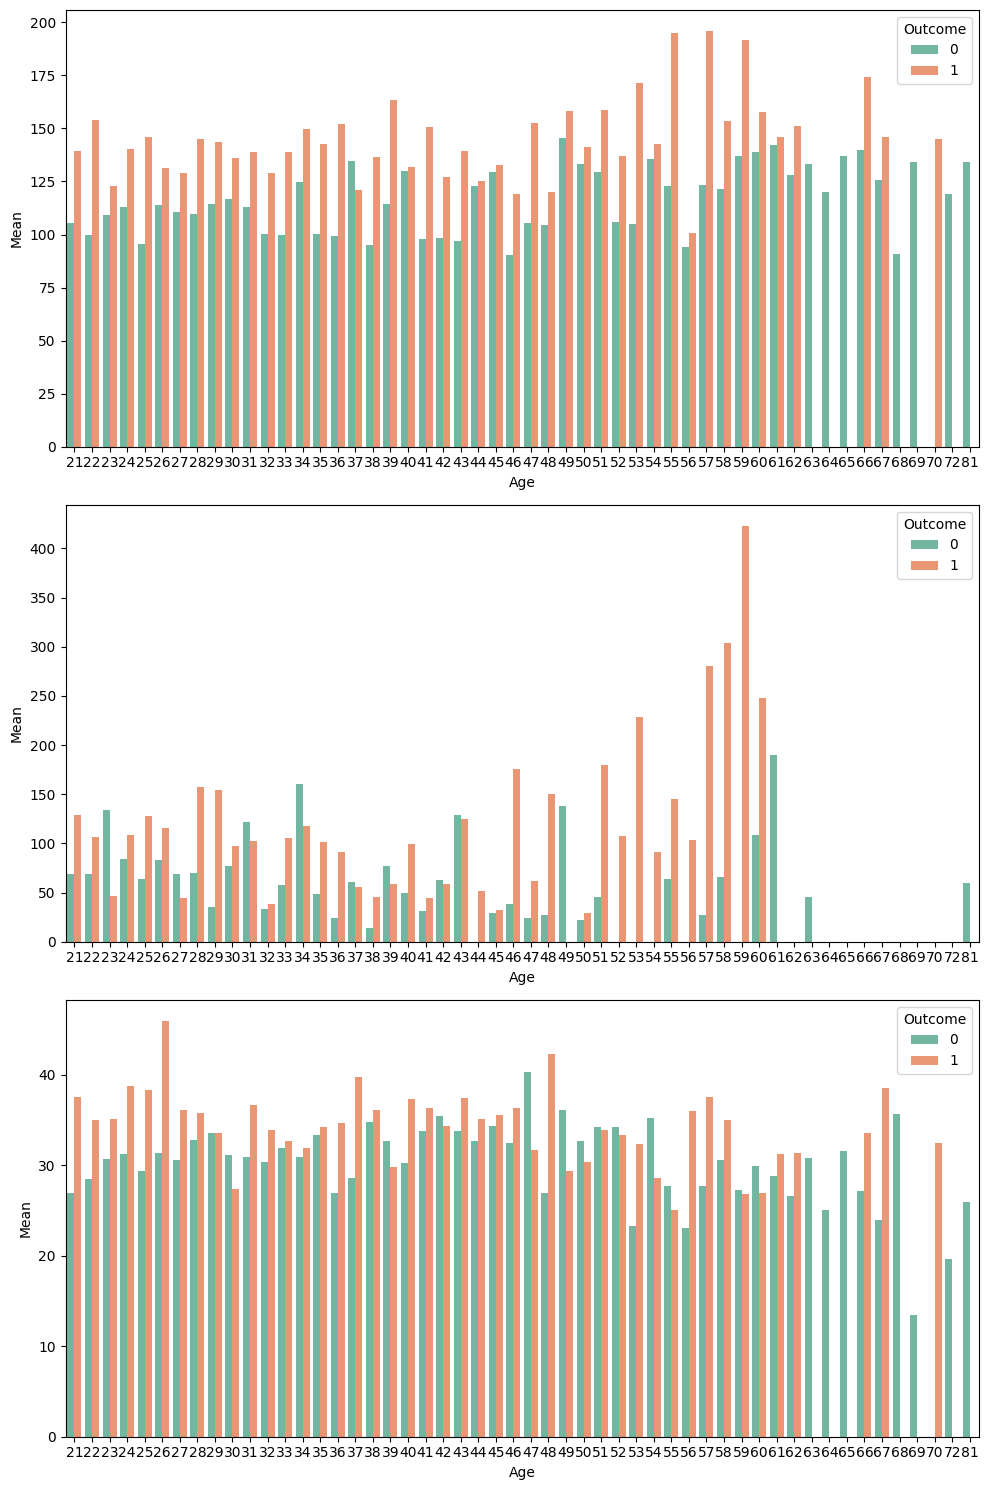

In [45]:
list1 = ['Age', 'Glucose','Outcome']
list2 = ['Age', 'Insulin','Outcome']
list3 = ['Age', 'BMI','Outcome']
variable_lists = [list1,list2,list3]
EDA.multivariate_barplots(raw_df, variable_lists,y='mean',palette='Set2')

At all ages, a high BMI appears to indicate a higher probability of having diabetes. At all ages, people with diabetes have higher glucose levels. At older ages, people with diabetes have higher insulin levels.

It is also observed that in the dataset, there are few older people who have diabetes.

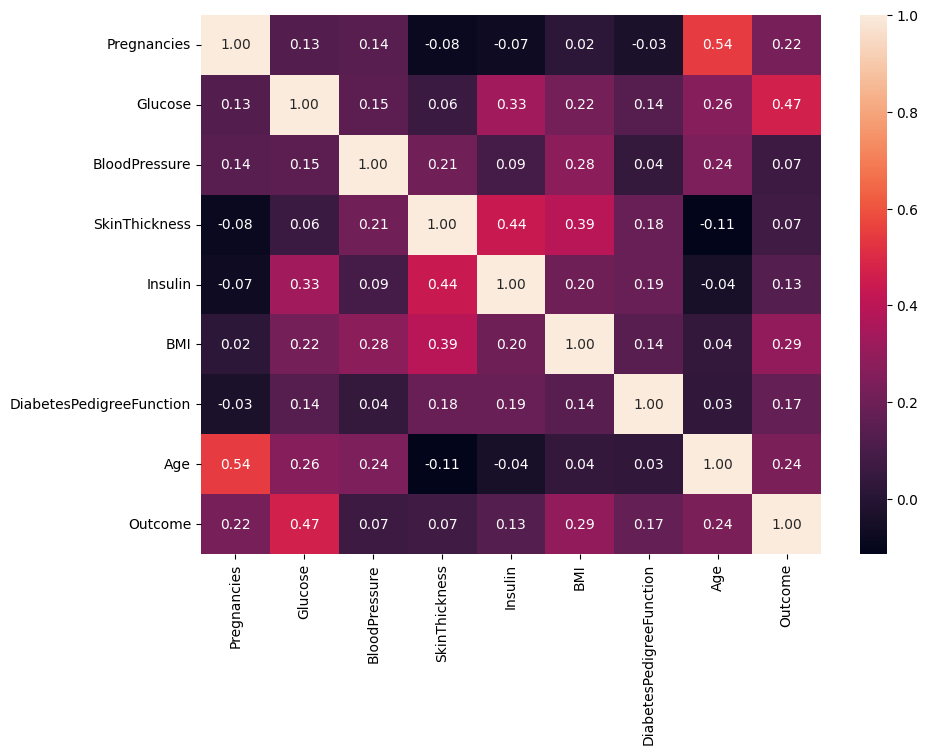

In [46]:
_, df = EDA.correlation_matrix(raw_df, [],(10,7))

Of the 9 features we have, only blood pressure may not be determinative, so we will perform feature selection leaving 8 features.

### 5. Feature engineering
#### 5.1 Outliers

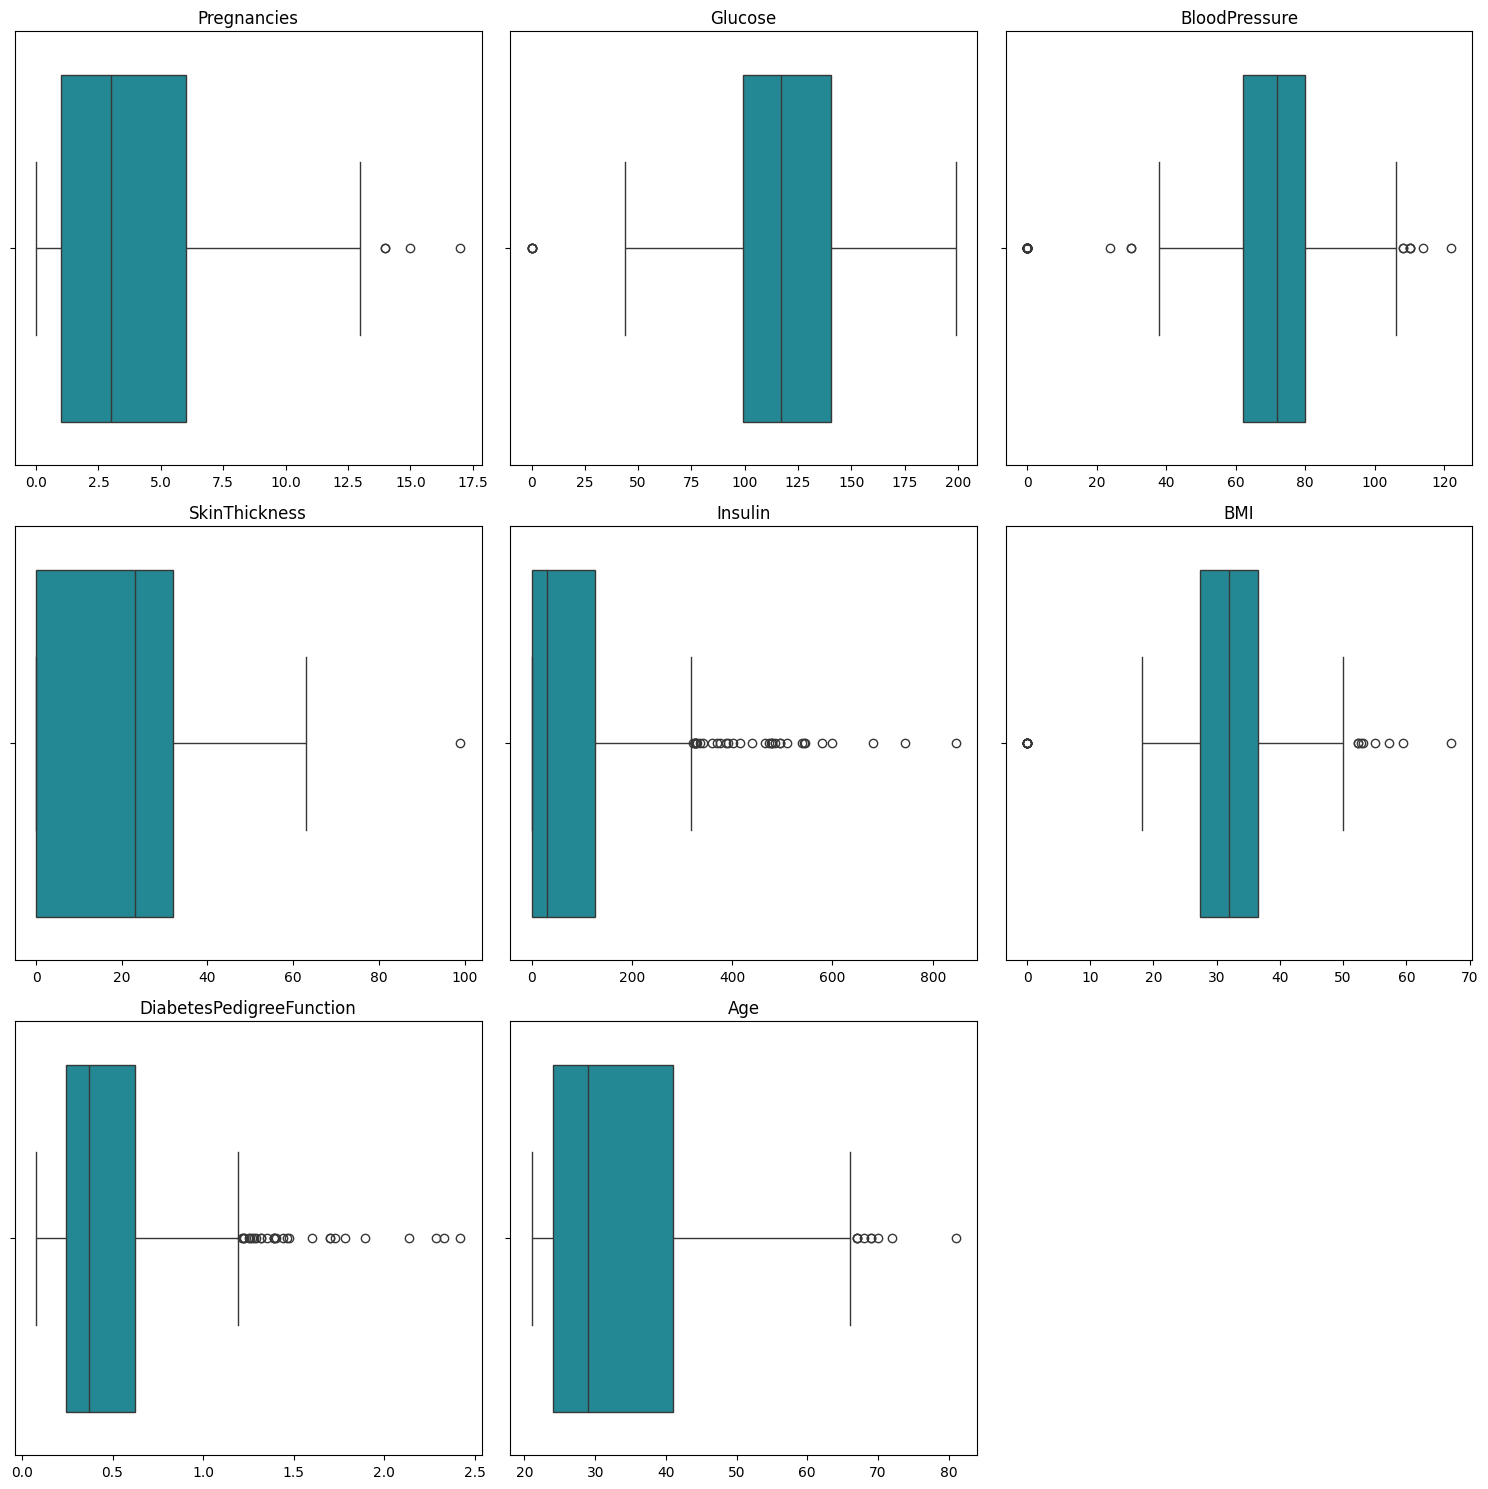

In [47]:
features = [col for col in list(df.columns) if col != 'Outcome']

EDA.numerical_box(features, df)

In [48]:
clean_df = df.copy()
by_mean = ['Glucose', 'BloodPressure','BMI']
by_mode = ['Pregnancies','SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'Age']
from edastatmil_milser.edas_tatmil import Do_enum

In [49]:
by_mean_outliers_list=[]
for col in by_mean:
    mean_outliers, clean_df = EDA.outliers_iqr(clean_df, col,2, Do=Do_enum.MEAN)
    by_mean_outliers_list.append(mean_outliers)
by_mean_outliers = pd.concat(by_mean_outliers_list, ignore_index=True)

222.75 16.5
5 outliers have been treated by replacing them with the mean
116.0 26.0
37 outliers have been treated by replacing them with the mean
55.2 8.7
14 outliers have been treated by replacing them with the mean


In [50]:
by_mode_outliers_list=[]
for col in by_mode:
    mode_outliers, clean_df = EDA.outliers_iqr(clean_df, col,1.5, Do=Do_enum.MODE)
    by_mode_outliers_list.append(mode_outliers)
by_mode_outliers = pd.concat(by_mode_outliers_list, ignore_index=True)

13.5 -6.5
4 outliers have been treated by replacing them with the mode
80.0 -48.0
1 outliers have been treated by replacing them with the mode
318.125 -190.875
34 outliers have been treated by replacing them with the mode
1.2 -0.32999999999999996
29 outliers have been treated by replacing them with the mode
66.5 -1.5
9 outliers have been treated by replacing them with the mode


In [51]:
outliers = pd.concat([by_mean_outliers,by_mode_outliers],ignore_index=True)

In [52]:
by_mean_outliers.to_csv('../data/processed/NonSplit/Outliers-Glu-Bold-BMI.csv')
by_mean_outliers.to_csv('../data/processed/NonSplit/Outliers-Preg-Skin-Ins-Diab-Age.csv')
outliers.to_csv('../data/processed/NonSplit/Outliers-All.csv')
clean_df.to_csv('../data/processed/Clean.csv')
df.to_csv('../data/processed/All.csv')

#### 5.2 Split data

In [53]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [54]:
predictors = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
target = 'Outcome'
EDA.splitter('../data/processed/', predictors, target)

{'All_Xtrain':      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 334            1       95             60             18       58  23.9   
 139            5      105             72             29      325  36.9   
 485            0      135             68             42      250  42.3   
 547            4      131             68             21      166  33.1   
 18             1      103             30             38       83  43.3   
 ..           ...      ...            ...            ...      ...   ...   
 71             5      139             64             35      140  28.6   
 106            1       96            122              0        0  22.4   
 270           10      101             86             37        0  45.6   
 435            0      141              0              0        0  42.4   
 102            0      125             96              0        0  22.5   
 
      DiabetesPedigreeFunction  Age  
 334                     0.260   22  
 139    

#### 5.3 Normalize data

In [55]:
EDA.normalize('../data/processed/SplitData/',predictors,scaler='StandardScaler')

{'All_Xtest_norm':      Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
 0       0.523387 -0.739446      -0.444600       0.720042  0.956067  0.232733   
 1      -0.590921 -0.289349       0.329998       0.661122 -0.691043  0.433777   
 2      -0.590921 -0.417948      -0.171213      -1.224301 -0.691043 -0.145702   
 3       1.080541 -0.450098       0.557822      -1.224301 -0.691043 -0.878919   
 4       0.801964  0.482248       1.013468      -1.224301 -0.691043 -0.252136   
 ..           ...       ...            ...            ...       ...       ...   
 226    -1.148075 -0.064300      -3.087349      -1.224301 -0.691043  0.043516   
 227    -0.033767 -0.385798      -0.171213       1.368156  0.167188  0.327342   
 228    -1.148075  0.192899       0.557822       0.955720  1.129447  0.504733   
 229     0.523387 -0.514398       0.102175       0.661122 -0.101551 -0.145702   
 230     0.244810 -1.414593       0.648951       1.191398 -0.326945  0.445603   
 
      Di

#### 5.4 Selection

In [56]:
Xtrain_All = pd.read_csv('../data/processed/SplitData/NormData/All_Xtrain_norm.csv')
ytrain_All = pd.read_csv('../data/processed/SplitData/All_ytrain.csv')

Xtrain_Clean = pd.read_csv('../data/processed/SplitData/NormData/Clean_Xtrain_norm.csv')
ytrain_Clean = pd.read_csv('../data/processed/SplitData/Clean_ytrain.csv')

In [57]:
EDA.feature_sel(Xtrain_All,ytrain_All,k=7,file_name='All_Xtrain', method='SelectKBest', test='mutual_info_regression')

EDA.feature_sel(Xtrain_Clean,ytrain_Clean,k=7,file_name='Clean_Xtrain', method='SelectKBest', test='mutual_info_regression')

/home/vscode/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/vscode/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


(     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
 0      -0.841271 -0.895858      -1.023597      -0.157146 -0.016353 -1.233997   
 1       0.442145 -0.563749      -0.009788       0.553619 -0.772052  0.708817   
 2      -1.162125  0.432578      -0.347724       1.393614  2.485270  1.515832   
 3       0.121291  0.299735      -0.347724       0.036699  1.390810  0.140918   
 4      -0.841271 -0.630171      -3.558121       1.135154  0.309379  1.665279   
 ..           ...       ...            ...            ...       ...       ...   
 532     0.442145  0.565422      -0.685661       0.941309  1.052048 -0.531595   
 533    -0.841271 -0.862647      -0.254330      -1.320215 -0.772052 -1.458167   
 534     2.046415 -0.696592       1.172990       1.070539 -0.772052  2.009008   
 535    -1.162125  0.631844      -0.254330      -1.320215 -0.772052  1.530777   
 536    -1.162125  0.100469       2.017831      -1.320215 -0.772052 -1.443223   
 
           Age  
 0   -0.9

In [58]:
Xtrain_All_Sel = pd.read_csv('../data/processed/SplitData/FeatureSel/All_Xtrain_FeatureSel.csv')

Xtrain_Clean_Sel = pd.read_csv('../data/processed/SplitData/FeatureSel/Clean_Xtrain_FeatureSel.csv')

In [59]:
Xtrain_All_Sel.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [60]:
Xtrain_Clean_Sel.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Age'],
      dtype='object')

In [61]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Indeed, the feature selection removes the blood pressure column, as suspected.

### 6. Decission Tree Model
#### 6.1 Init and train

In [62]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree
from pickle import dump
from sklearn.metrics import accuracy_score

All_model = DecisionTreeClassifier(random_state = 42)
All_model.fit(Xtrain_All_Sel, ytrain_All )
dump(All_model, open("../data/processed/Models/All_decision_tree_regressor_default_42.sav", "wb"))

[Text(0.5933407738095238, 0.9666666666666667, 'Glucose <= 1.042\ngini = 0.455\nsamples = 537\nvalue = [349, 188]\nclass = 0'),
 Text(0.2819196428571429, 0.9, 'Age <= -0.392\ngini = 0.383\nsamples = 454\nvalue = [337, 117]\nclass = 0'),
 Text(0.15119047619047618, 0.8333333333333334, 'Glucose <= 0.206\ngini = 0.22\nsamples = 238\nvalue = [208, 30]\nclass = 0'),
 Text(0.08333333333333333, 0.7666666666666667, 'BMI <= 2.248\ngini = 0.117\nsamples = 192\nvalue = [180, 12]\nclass = 0'),
 Text(0.07380952380952381, 0.7, 'BMI <= -0.076\ngini = 0.1\nsamples = 190\nvalue = [180, 10]\nclass = 0'),
 Text(0.01904761904761905, 0.6333333333333333, 'DiabetesPedigreeFunction <= 0.591\ngini = 0.018\nsamples = 111\nvalue = [110, 1]\nclass = 0'),
 Text(0.009523809523809525, 0.5666666666666667, 'gini = 0.0\nsamples = 96\nvalue = [96, 0]\nclass = 0'),
 Text(0.02857142857142857, 0.5666666666666667, 'DiabetesPedigreeFunction <= 0.666\ngini = 0.124\nsamples = 15\nvalue = [14, 1]\nclass = 0'),
 Text(0.01904761904

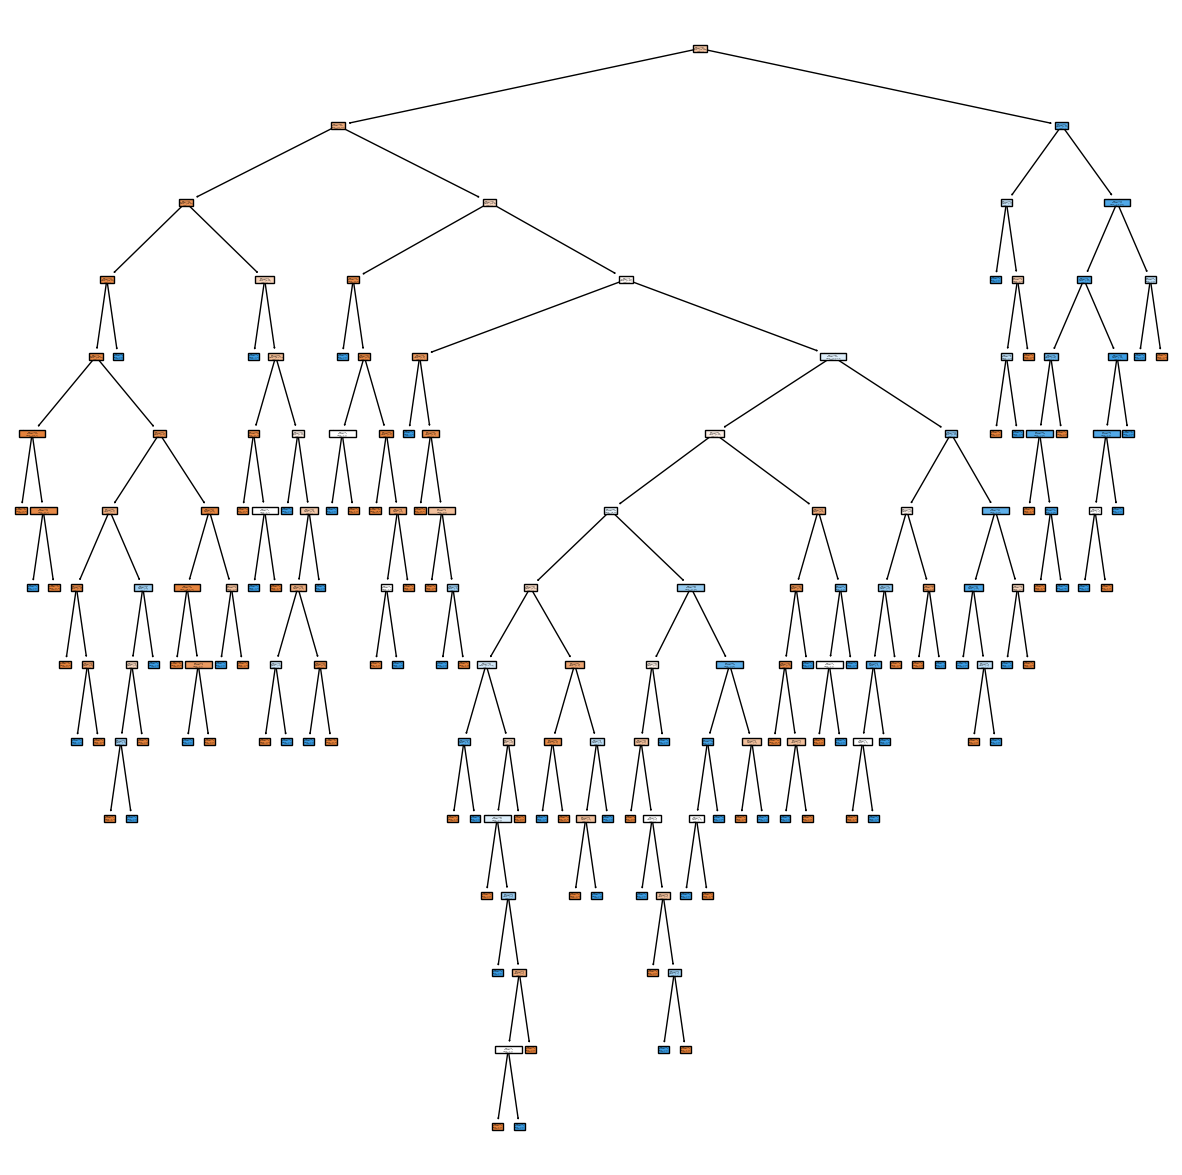

In [63]:
fig = plt.figure(figsize=(15,15))
tree.plot_tree(All_model, feature_names = list(Xtrain_All_Sel.columns), class_names = ["0", "1"], filled = True)

[Text(0.583554376657825, 0.9705882352941176, 'Glucose <= 1.08\ngini = 0.455\nsamples = 537\nvalue = [349, 188]\nclass = 0'),
 Text(0.32891246684350134, 0.9117647058823529, 'Age <= -0.357\ngini = 0.383\nsamples = 454\nvalue = [337, 117]\nclass = 0'),
 Text(0.17639257294429708, 0.8529411764705882, 'Glucose <= 0.183\ngini = 0.221\nsamples = 245\nvalue = [214.0, 31.0]\nclass = 0'),
 Text(0.08488063660477453, 0.7941176470588235, 'BMI <= 2.532\ngini = 0.116\nsamples = 195\nvalue = [183, 12]\nclass = 0'),
 Text(0.07427055702917772, 0.7352941176470589, 'BMI <= -0.113\ngini = 0.098\nsamples = 193\nvalue = [183, 10]\nclass = 0'),
 Text(0.021220159151193633, 0.6764705882352942, 'Pregnancies <= -0.36\ngini = 0.018\nsamples = 110\nvalue = [109, 1]\nclass = 0'),
 Text(0.010610079575596816, 0.6176470588235294, 'gini = 0.0\nsamples = 86\nvalue = [86, 0]\nclass = 0'),
 Text(0.03183023872679045, 0.6176470588235294, 'BMI <= -1.361\ngini = 0.08\nsamples = 24\nvalue = [23, 1]\nclass = 0'),
 Text(0.02122015

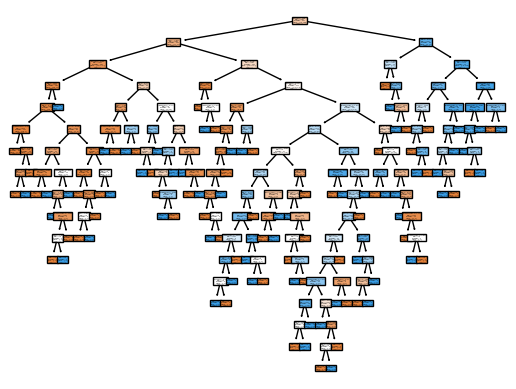

In [64]:
Clean_model = DecisionTreeClassifier(random_state = 42)
Clean_model.fit(Xtrain_Clean_Sel, ytrain_Clean )
dump(Clean_model, open("../data/processed/Models/Clean_decision_tree_regressor_default_42.sav", "wb"))

tree.plot_tree(Clean_model, feature_names = list(Xtrain_Clean_Sel.columns), class_names = ["0", "1"], filled = True)

### 6.2 Prediction

In [65]:
Xtest_All = pd.read_csv('../data/processed/SplitData/NormData/All_Xtest_norm.csv')
Xtest_All_Sel = Xtest_All[Xtrain_All_Sel.columns]
ytest_All = pd.read_csv('../data/processed/SplitData/All_ytest.csv')

Xtest_Clean = pd.read_csv('../data/processed/SplitData/NormData/Clean_Xtest_norm.csv')
Xtest_Clean_Sel = Xtest_Clean[Xtrain_Clean_Sel.columns]
ytest_Clean = pd.read_csv('../data/processed/SplitData/Clean_ytest.csv')

In [66]:
All_ypred = All_model.predict(Xtest_All_Sel)

Clean_ypred = Clean_model.predict(Xtest_Clean_Sel)

In [67]:
All_Acc = accuracy_score(ytest_All, All_ypred)
print('Accuracy with all data:',All_Acc)

Clean_Acc = accuracy_score(ytest_Clean, Clean_ypred)
print('Accuracy with clean data:',Clean_Acc)

Accuracy with all data: 0.70995670995671
Accuracy with clean data: 0.7012987012987013


Since, under equal conditions, the most accurate model is the one that uses the data replacing the outliers with the chosen metric, we will continue with the optimization of this one.

#### 6.3 Optimization

In [68]:
from sklearn.model_selection import GridSearchCV


In [69]:
""" BY DEFAULT
param_grid = {
    'criterion': ['gini'],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': [None, 'sqrt','log2',5,7]
}
"""
param_grid = {
    'criterion': ['gini', 'entropy','log_loss'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4,10],
    'max_features': [None,'sqrt','log2',5]
}

grid_search = GridSearchCV(estimator=Clean_model, param_grid=param_grid)
grid_search.fit(Xtrain_All_Sel, ytrain_All)

best_dt_model = grid_search.best_estimator_
dump(best_dt_model, open("../data/processed/Models/GridOptimize_All_model.sav", "wb"))
best_params = grid_search.best_params_
dump(best_dt_model, open("../data/processed/Models/GridOptimize_All_params.sav", "wb"))

y_pred = best_dt_model.predict(Xtest_All_Sel)
mse = accuracy_score(ytest_All, y_pred)

print("Best parameters:", best_params)
print("Accuracy:", mse)

Best parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Accuracy: 0.6926406926406926


In [70]:
optimal_model = DecisionTreeClassifier(criterion='gini', max_depth=7, max_features=None,min_samples_leaf=4, min_samples_split=20,random_state = 42)
optimal_model.fit(Xtrain_All, ytrain_All)
dump(Clean_model, open("../data/processed/Models/DTree-crit_gini-depth_7-maxf_none-minleaf_4-minsplit_20.sav", "wb"))

In [71]:
Xtrain_All.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')